In [2]:
#packages and reqs
import torch
import sentence_transformers #as it given in the HW
import sklearn
import rank_bm25
import pandas as pd
import numpy as np

print(f"torch: {torch.__version__}")
print(f"sentence-transformers: {sentence_transformers.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"rank-bm25: installed")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

torch: 2.11.0+cpu
sentence-transformers: 5.4.1
scikit-learn: 1.8.0
rank-bm25: installed
pandas: 3.0.2
numpy: 2.4.4


In [3]:
#random seed
import random
SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [6]:
#loading documnents
import sys
sys.path.insert(0, '.')
from documents import iso_5338_summaries

doc_keys = list(iso_5338_summaries.keys())
doc_texts = list(iso_5338_summaries.values())
doc_id_map = {k:i for i, k in enumerate(doc_keys)}

print(f"Total documents: {len(doc_keys)}")
print("First 3 keys: ", doc_keys[:3])

Total documents: 33
First 3 keys:  ['Acquisition Process (6.1.1)', 'Supply Process (6.1.2)', 'Life Cycle Model Management Process (6.2.1)']


In [8]:
#csv
df = pd.read_csv('td_cases_train_4.csv')
df = df.rename(columns={'Unnamed: 0':'idx'})

print(df.shape)
df.head(3)

(365, 5)


,idx,case_description,root_cause,golden_doc,golden_id
0,0,Inability to obtain the data scraped from comm...,Data formats change over time in the third-par...,Design Definition Process (6.4.5),20
1,1,Ambiguity in the labeling protocol,-,System Requirements Definition Process (6.4.3),18
2,2,"Problems in data retrieval via API, such as in...",Poor data pipeline decisions,Decision Management Process (6.3.3),10


In [9]:
#creating query column

def query_text(row):
    rc = str(row['root_cause']) if str (row['root_cause']) != '_' else ''
    return str(row['case_description']) + ' ' + rc

df['query'] = df.apply(query_text, axis=1)
print(df['query'].head(3).to_string())

0    Inability to obtain the data scraped from comm...
1                 Ambiguity in the labeling protocol -
2    Problems in data retrieval via API, such as in...


In [10]:
#loading the model and embed the documents
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(doc_texts, convert_to_tensor=True, show_progress_bar=True)
print("Document embeddings shape:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Document embeddings shape: torch.Size([33, 384])


In [11]:
#moving onto part 1
#first question: Whether each document is referenced by queries more than once?
ref_counts = df['golden_doc'].value_counts()
print(ref_counts.to_string())

golden_doc
AI Data Engineering Process (6.4.8)                              64
Quality Assurance Process (6.3.8)                                48
System Requirements Definition Process (6.4.3)                   30
Implementation Process (6.4.9)                                   22
Risk Management Process (6.3.4)                                  22
Project Planning Process (6.3.1)                                 20
Configuration Management Process (6.3.5)                         17
Acquisition Process (6.1.1)                                      17
Quality Management Process (6.2.5)                               13
Human Resource Management Process (6.2.4)                        13
Design Definition Process (6.4.5)                                12
Decision Management Process (6.3.3)                              11
Infrastructure Management Process (6.2.2)                        11
Knowledge Management Process (6.2.6)                             10
Operation Process (6.4.15)           

In [12]:
#part1 second q:  Whether there are documents that are not referenced by any query. 
never_referenced = [k for k in doc_keys if k not in ref_counts.index]
print(f"Never referenced ({len(never_referenced)} docs):")
for d in never_referenced:
    print(' -',d)

Never referenced (8 docs):
 - Supply Process (6.1.2)
 - Life Cycle Model Management Process (6.2.1)
 - Measurement Process (6.3.7)
 - Business or Mission Analysis Process (6.4.1)
 - System Architecture Definition Process (6.4.4)
 - System Analysis Process (6.4.6)
 - Knowledge Acquisition Process (6.4.7)
 - Disposal Process (6.4.17)


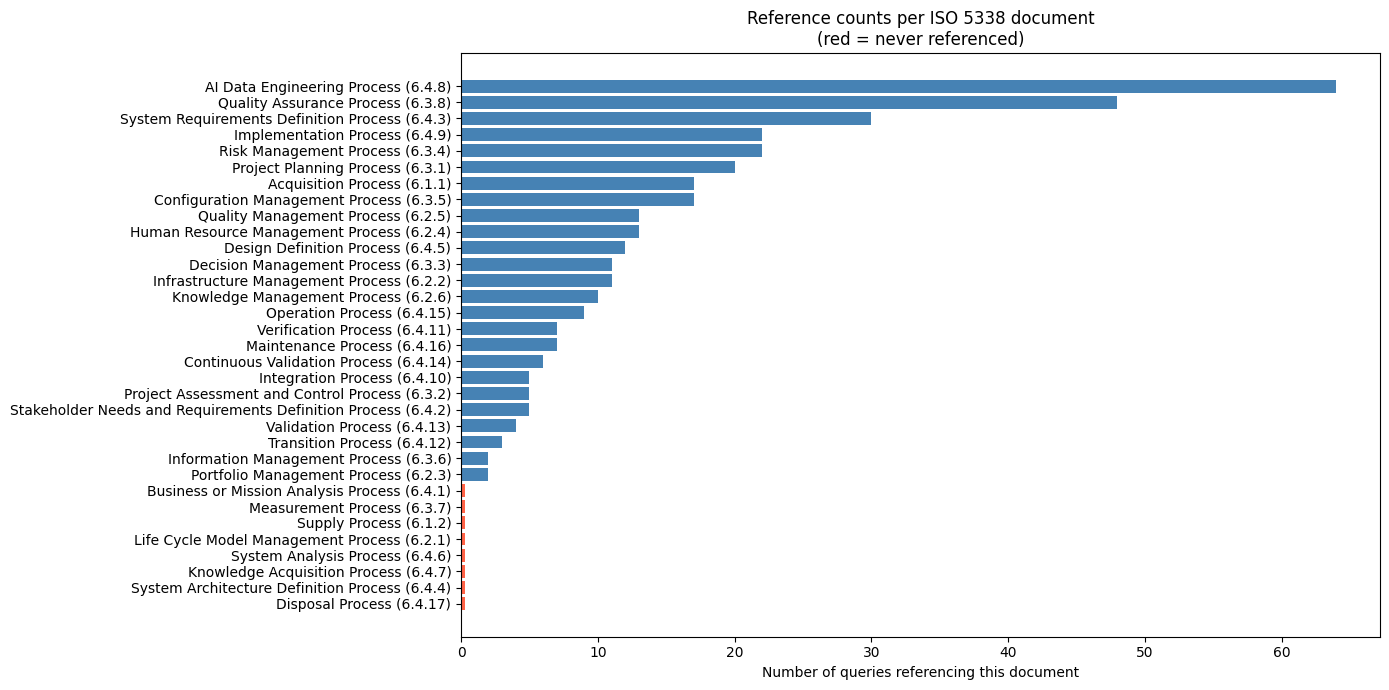

In [29]:
#bar chart for the analysis
import matplotlib.pyplot as plt
all_ref = pd.Series({k: ref_counts.get(k, 0) for k in doc_keys})
all_ref_sorted = all_ref.sort_values(ascending=False)

colors = ['steelblue' if v > 0 else 'tomato' for v in all_ref_sorted.values]

display_values = [v if v>0 else 0.3 for v in all_ref_sorted.values] #i make 0's to 0.3 so that we can see  their values so its made just for visualisation
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(all_ref_sorted.index, display_values, color=colors)
ax.set_xlabel('Number of queries referencing this document')
ax.set_title('Reference counts per ISO 5338 document\n(red = never referenced)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_ref_counts.png', dpi=300) #in the HW it is given as DPI >= 300
plt.show()

In [33]:
#part 1 3rd q:  Whether the queries and their associated documents share keywords or concepts?
#i'm gonna calculate cosine similarity using tf-idf, and compare everyquery with its own golden doc

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

overlap_scores = []
for _, row in df.iterrows():
    q = row['query']
    doc = iso_5338_summaries[row['golden_doc']]
    tfidf = TfidfVectorizer(stop_words = 'english')
    mat = tfidf.fit_transform([q, doc])
    sim = cosine_similarity(mat[0], mat[1]) [0][0]
    overlap_scores.append(sim)

df['tfidf_overlap'] = overlap_scores

print(f"Mean: {np.mean(overlap_scores): .4f}")
print(f"Median: {np.median(overlap_scores): .4f}")
print(f"std: {np.std(overlap_scores):.4f}")

Mean:  0.0882
Median:  0.0512
std: 0.1036


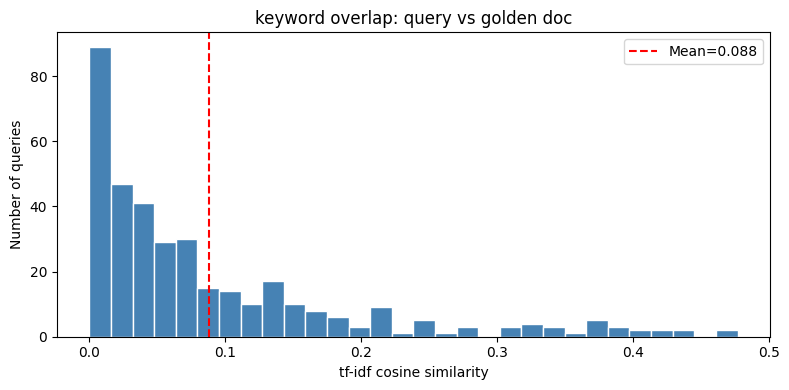

In [34]:
#histogram plot
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(overlap_scores, bins =30, color='steelblue', edgecolor='white')
ax.axvline(np.mean(overlap_scores), color='red', linestyle='--', label=f'Mean={np.mean(overlap_scores):.3f}')
ax.set_xlabel('tf-idf cosine similarity')
ax.set_ylabel('Number of queries')
ax.set_title('keyword overlap: query vs golden doc')
ax.legend()
plt.tight_layout()
plt.savefig('fig_tfidf_overlap.png', dpi=300)
plt.show()

In [35]:
#PART 2 
query_embeddings = model.encode(df['query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("query embeddings shape:", query_embeddings.shape)                                

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

query embeddings shape: torch.Size([365, 384])


In [37]:
#calc cosine similarity and create ranked list
cosine_scores = util.cos_sim(query_embeddings, doc_embeddings) #365, 365
ranked_indices = torch.argsort(cosine_scores, dim=1, descending=True).cpu().numpy()

print("cosine_scores shape:", cosine_scores.shape)
print("ranked_indices shape:", ranked_indices.shape)

cosine_scores shape: torch.Size([365, 33])
ranked_indices shape: (365, 33)


In [44]:
def hit_at_k(ranked, golden_id, k):
    return int(golden_id in ranked[:k].tolist())

def ndcg_at_k(ranked, golden_id, k):
    top_k = ranked[:k].tolist()
    if golden_id not in top_k:
        return 0.0
    rank = list(top_k).index(golden_id) +1
    dcg = 1.0 / np.log2(rank +1)
    idcg = 1.0/np.log2(1+1)
    return dcg/idcg

def compute_metrics(ranked_indices, golden_ids, ks=(1, 3, 5)):
    results = {}
    for k in ks: 
        hits = [hit_at_k(r, g, k) for r, g in zip(ranked_indices, golden_ids)]
        ndcgs = [ndcg_at_k(r, g, k) for r, g in zip(ranked_indices, golden_ids)]
        results[f'Hit@{k}'] = np.mean(hits)
        results[f'NDCG@{k}'] = np.mean(ndcgs)
    return results
print("metrics function defined")

metrics function defined


In [45]:
golden_ids = df['golden_id'].tolist()

dense_metrics = compute_metrics(ranked_indices, golden_ids)
print("dense retrieval metrics:")
for k, v, in dense_metrics.items():
    print(f" {k}: {v:.4f}")

dense retrieval metrics:
 Hit@1: 0.1178
 NDCG@1: 0.1178
 Hit@3: 0.3068
 NDCG@3: 0.2245
 Hit@5: 0.4000
 NDCG@5: 0.2627


In [46]:
#failure case
failure_cases = []
for i, (ranked, gid) in enumerate(zip(ranked_indices, golden_ids)):
    rank = list(ranked).index(gid)+1
    if rank > 5:
        failure_cases.append({
            'row_idx': i,
            'golden_rank': rank,
            'golden_doc': df.iloc[i]['golden_doc'],
            'top1_doc': doc_keys[ranked[0]],
            'case_description': df.iloc[i]['case_description'],
            'root_cause': df.iloc[i]['root_cause'],
        })
print(f"total failure cases (rank > 5): {len(failure_cases)}")
print(f"first 5:")
for fc in failure_cases[:5]:
    print(f"\n  Row {fc['row_idx']} | Rank: {fc['golden_rank']}")
    print(f"  Golden: {fc['golden_doc']}")
    print(f"  Top-1: {fc['top1_doc']}")
    print(f"  Case: {fc['case_description']}")
    print(f"  Cause: {fc['root_cause']}")


total failure cases (rank > 5): 219
first 5:

  Row 0 | Rank: 26
  Golden: Design Definition Process (6.4.5)
  Top-1: Business or Mission Analysis Process (6.4.1)
  Case: Inability to obtain the data scraped from commercial sites
  Cause: Data formats change over time in the third-party data source

  Row 2 | Rank: 13
  Golden: Decision Management Process (6.3.3)
  Top-1: AI Data Engineering Process (6.4.8)
  Case: Problems in data retrieval via API, such as incorrect parsing, fetching unnecessary data, and not testing data acquisition
  Cause: Poor data pipeline decisions

  Row 3 | Rank: 6
  Golden: Validation Process (6.4.13)
  Top-1: Project Planning Process (6.3.1)
  Case: Lack of comprehensive testing in ML projects before deployment
  Cause: The need for testers specifically in the ML domain

  Row 4 | Rank: 14
  Golden: AI Data Engineering Process (6.4.8)
  Top-1: Measurement Process (6.3.7)
  Case: Out-of-distribution (OOD) examples or novelty detection
  Cause: Pandemic affec

In [47]:
selected_failures = failure_cases[:5]
print("5 failure cases saved")

5 failure cases saved


In [48]:
import wandb
wandb.login() #wandb integration

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ozgu.ozkan\_netrc.
wandb: Network error (SSLError), entering retry loop.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [53]:
import re
from rank_bm25 import BM25Okapi

def tokenize(text):
    return re.sub(r'[^a-zA-Z0-9 ]', ' ', text.lower()).split() #regex

tokenized_docs =[tokenize(d) for d in doc_texts]
bm25 = BM25Okapi(tokenized_docs)
print("BM25 index built")

BM25 index built


In [54]:
def hybrid_retrieve(query_text, query_emb, alpha, bm25, doc_embeddings):
    #bm25 scores
    bm25_raw = np.array(bm25.get_scores(tokenize(query_text)), dtype=np.float32)
    bm25_min, bm25_max = bm25_raw.min(), bm25_raw.max()
    if bm25_max - bm25_min > 0:
        bm25_norm = np.zeros_like(bm25_raw)

    cos_raw = util.cos_sim(query_emb, doc_embeddings).cpu().numpy().flatten().astype(np.float32) #dense cosine scores
    cos_min, cos_max = cos_raw.min(), cos_raw.max()
    if cos_max - cos_min > 0:
        cos_norm = (cos_raw - cos_min) / (cos_max - cos_min)
        if cos_max - cos_min > 0:
            cos_norm = (cos_raw - cos_min) / (cos_max - cos_min)
        else:
            cos_norm = np.zeros_like(cos_raw)

        combined = alpha * bm25_norm + (1 - alpha) * cos_norm
        return np.argsort(combined)[:: -1]

print("hybrid retriever defined")                    

hybrid retriever defined


In [59]:
import os

os.environ["WANDB_ENTITY"] = "ozgukan"
os.environ["WANDB_PROJECT"] = "nlp_assign3"

In [60]:
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_results = []
for alpha in alpha_values:
    run = wandb.init(
        project="nlp_assign3",
        entity="ozgukan",
        name=f"alpha_{alpha:.1f}",
        config={'alpha': alpha, 'model': 'all-MiniLM-L6-v2'},
        reinit=True
    )
    ranked_hybrid = []
    for i, row in df.iterrows():
        ranked = hybrid_retrieve(row['query'], query_embeddings[i], alpha, bm25, doc_embeddings)
        ranked_hybrid.append(ranked)

    metrics = compute_metrics(ranked_hybrid, golden_ids)
    metrics['alpha'] = alpha
    sweep_results.append(metrics)
    wandb.log(metrics)
    run.finish()
    print(f"alpha={alpha:.1f}  Hit@1={metrics['Hit@1']:.4f}  Hit@5={metrics['Hit@5']:.4f}")
sweep_df = pd.DataFrame(sweep_results).set_index('alpha')
print("\nsweep complete")

wandb: Network error (SSLError), entering retry loop.


Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0.11781
Hit@3,0.30685
Hit@5,0.4
NDCG@1,0.11781


alpha=0.0  Hit@1=0.1178  Hit@5=0.4000


Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0.11781
Hit@3,0.30685
Hit@5,0.4
NDCG@1,0.11781


alpha=0.1  Hit@1=0.1178  Hit@5=0.4000


...

Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0.11781
Hit@3,0.30685
Hit@5,0.4
NDCG@1,0.11781


alpha=0.9  Hit@1=0.1178  Hit@5=0.4000


wandb: Network error (SSLError), entering retry loop.


Hit@1,▁
Hit@3,▁
Hit@5,▁
NDCG@1,▁
NDCG@3,▁
NDCG@5,▁
alpha,▁
Hit@1,0
Hit@3,0.04384
Hit@5,0.07123
NDCG@1,0


alpha=1.0  Hit@1=0.0000  Hit@5=0.0712

sweep complete


In [61]:
print(sweep_df.to_string())

          Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
alpha                                                            
0.0    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.1    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.2    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.3    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.4    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.5    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.6    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.7    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.8    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
0.9    0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
1.0    0.000000  0.000000  0.043836  0.024429  0.071233  0.035748


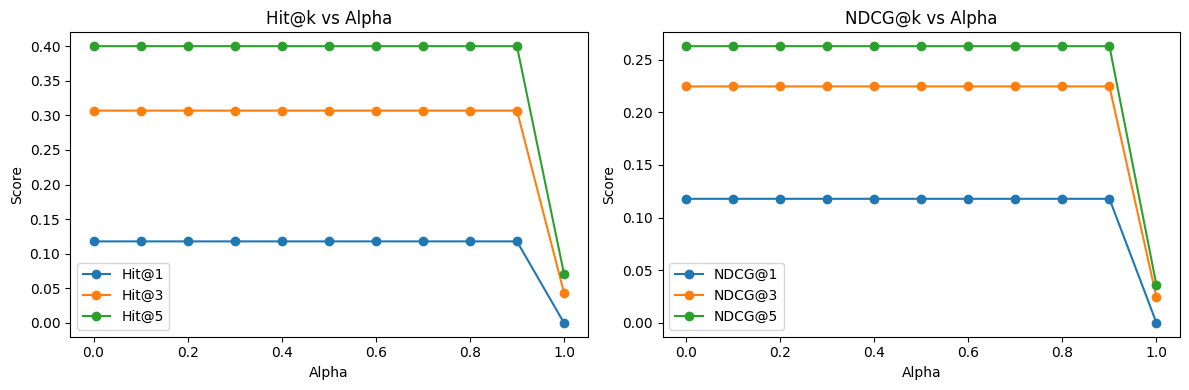

In [64]:
#visualisation
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for metric in ['Hit@1', 'Hit@3', 'Hit@5']:
    axes[0].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Score')
axes[0].set_title('Hit@k vs Alpha')
axes[0].legend()

for metric in ['NDCG@1', 'NDCG@3', 'NDCG@5']:
    axes[1].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Score')
axes[1].set_title('NDCG@k vs Alpha')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_alpha_sweep.png', dpi=300)
plt.show()

In [65]:
best_alpha = sweep_df['Hit@1'].idxmax()
print(f"Best alpha by Hit@1: {best_alpha}")

Best alpha by Hit@1: 0.0


In [70]:
#i am using ollama for part 4
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "llama3.2",
        "prompt": "Say hello!",
        "stream": False
    }
)
print(response.json()['response'])

Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [71]:
# prompts

SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Your task is to rephrase practitioner descriptions of technical debt cases into formal process-oriented language that matches the vocabulary and style of ISO 5338 process descriptions.

Rules:
- Do NOT add new facts. Only translate the given description into ISO-standard language.
- Use process-oriented vocabulary: outcomes, activities, artefacts, stakeholders, traceability, verification, validation, configuration, requirements, architecture, data engineering, etc.
- Output ONLY the rephrased query. No preamble, no explanation."""

def rewrite_query(case_description, root_cause):
    rc_text = root_cause if str(root_cause) != '-' else ''
    prompt = f"{SYSTEM_PROMPT}\n\nCase description: {case_description}\nRoot cause: {rc_text}"
    
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3.2",
            "prompt": prompt,
            "stream": False
        }
    )
    return response.json()['response'].strip()

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

Activity: 'Monitor third-party data source' - Outcome: Maintainable configuration of artefacts 'data scraping scripts' and 'data format mappings'.

 Activity: 'Implement flexible data mapping mechanisms' - Outcome: Configuration artefact 'data format mapping configuration' is maintained up-to-date.

Activity: 'Perform regular data quality checks on data sources' - Outcome: Validation artefact 'data source quality validation report' is reviewed by stakeholders.

 Activity: 'Update requirements for data scraping and processing' - Outcome: Stakeholder-approved requirements document 'Commercial Data Scraping Requirements'.

 Activity: 'Develop data format mapping configurations in accordance with evolving third-party data formats' - Outcome: Artefact 'data format mapping configuration' reflects approved change to third-party data source format.


In [76]:
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Rephrase the given technical debt case into a single, concise declarative sentence using formal ISO process standard vocabulary.

Rules:
- Output ONE declarative sentence only. No questions, no bullet points, no lists, no preamble.
- Use process-oriented vocabulary: outcomes, activities, artefacts, stakeholders, traceability, verification, validation, configuration, requirements, data engineering, etc.
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

The artefact of 'third-party data' is not conformant with its required format due to ongoing changes, preventing successful data scraping and rendering it ineligible for verification and validation.


In [77]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:39<00:00,  2.29it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                                                                                        rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source                                                                                                                   Data scraping artefacts and related data integration processes are not traceable due to unvalidated and unreconfigurable changes to third-party data source formats.
1                                                                                                                     Ambiguity

In [78]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [79]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")


rewrittn query mtrics
  Hit@1: 0.1014
  NDCG@1: 0.1014
  Hit@3: 0.2493
  NDCG@3: 0.1850
  Hit@5: 0.3507
  NDCG@5: 0.2263


In [80]:
#prompt deneme 2
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023, the international standard for AI system life cycle processes.
Rephrase the given technical debt case using keywords and terminology from ISO 5338 process names and descriptions.

Rules:
- Output ONE declarative sentence only. No questions, no bullet points, no preamble.
- Prioritize using exact ISO 5338 process-related terms such as: data engineering, requirements definition, quality assurance, risk management, configuration management, verification, validation, implementation, acquisition, project planning, stakeholder needs, system architecture, design definition, knowledge management, operation, maintenance.
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

The project is unable to complete its verification process due to unmanaged changes in the third-party data source's system architecture and configuration, affecting the data acquisition process.


In [81]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:44<00:00,  2.21it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                        rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source      This project is hindered by an unvalidated acquisition process due to changing configuration management of third-party data sources, specifically a lack of verification and validation of data scraping outputs.
1                                                                                                                     Ambiguity in the labeling protocol -                                                         The ambiguity in the labeling protocol is a 

In [84]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [85]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")


rewrittn query mtrics
  Hit@1: 0.0548
  NDCG@1: 0.0548
  Hit@3: 0.1616
  NDCG@3: 0.1132
  Hit@5: 0.2630
  NDCG@5: 0.1541


In [86]:
#prompt deneme 3
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023 AI system life cycle processes.
Given a technical debt case from an AI project, rewrite it as a formal process issue description.

Rules:
- ONE declarative sentence only. No questions, no lists.
- Describe what process activity failed or was neglected.
- Use terms like: data acquisition, labeling, requirements, planning, configuration, quality assurance, risk, verification, validation, implementation, maintenance, operation.
- Do NOT add new facts."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

During the configuration phase of the AI system life cycle process, failure to update and adapt the data acquisition scripts in a timely manner resulted in the inability to access the required data from the third-party commercial site.


In [87]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:53<00:00,  2.10it/s]


done
                                                                                                                                                     query                                                                                                                                                                                                                                                                                                                           rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source  Formal Process Issue Description:\n\nThe failed planning activity of data acquisition for AI model training resulted in an inability to obtain the required data, due to the dynamic nature of the third-party data source where changes in data format have caused disruption to our ability to scrape and retrieve the necessary data.
1                        

In [88]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [89]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")

rewrittn query mtrics
  Hit@1: 0.0740
  NDCG@1: 0.0740
  Hit@3: 0.2110
  NDCG@3: 0.1522
  Hit@5: 0.3260
  NDCG@5: 0.1995


In [90]:
#prompt deneme 4
SYSTEM_PROMPT = """You are an expert in ISO/IEC 5338:2023 AI system life cycle processes.
Below is a technical debt case from an AI project. Rewrite it as if it were a description of a process failure within an ISO 5338 life cycle process.

Rules:
- ONE declarative sentence only. No questions, no bullet points, no preamble.
- Write in the style of an ISO process description: focus on which process activity was neglected, which artefact was missing, or which outcome was not achieved.
- Use passive voice where appropriate (e.g. 'data acquisition activities were not defined', 'requirements were not traced').
- Do NOT add new facts, only rephrase."""

# Test
print(rewrite_query("Inability to obtain the data scraped from commercial sites", 
                    "Data formats change over time in the third-party data source"))

Data acquisition activities for third-party data sources were not defined with consideration of evolving data formats.


In [91]:
#test is done, now i will rewrite the queries

from tqdm import tqdm
rewritten_queries = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    rq = rewrite_query(row['case_description'], row['root_cause'])
    rewritten_queries.append(rq)

df['rewritten_query'] = rewritten_queries
print("done")
print(df[['query', 'rewritten_query']].head(3).to_string())

100%|████████████████████████████████████████████████████████████████████████████████| 365/365 [02:09<00:00,  2.83it/s]


done
                                                                                                                                                     query                                                                                                                  rewritten_query
0                                  Inability to obtain the data scraped from commercial sites Data formats change over time in the third-party data source                                            Data acquisition activities for data scraping from commercial sites were not defined.
1                                                                                                                     Ambiguity in the labeling protocol -  Data annotation requirements were not properly documented and recorded within the project management information system (PMIS).
2  Problems in data retrieval via API, such as incorrect parsing, fetching unnecessary data, and not testing data acquisition Poor data pipelin

In [92]:
rw_embeddings = model.encode(df['rewritten_query'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print("rewritten query embeddings shape:", rw_embeddings.shape)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

rewritten query embeddings shape: torch.Size([365, 384])


In [93]:
#calculate the metrics with dense retrieval alpha = 0
rw_cosine = util.cos_sim(rw_embeddings, doc_embeddings)
rw_ranked = torch.argsort(rw_cosine, dim=1, descending=True).cpu().numpy()

rw_metrics = compute_metrics(rw_ranked, golden_ids)
print("rewrittn query mtrics")
for k, v in rw_metrics.items():
    print(f"  {k}: {v:.4f}")

rewrittn query mtrics
  Hit@1: 0.1205
  NDCG@1: 0.1205
  Hit@3: 0.2438
  NDCG@3: 0.1890
  Hit@5: 0.3315
  NDCG@5: 0.2253


In [96]:
#failure case analysis

print("failure case analysis: original and rewritten rank")
print()
for fc in selected_failures:
    i = fc['row_idx']
    gid=golden_ids[i]
    orig_rank = list(ranked_indices[i]).index(gid) + 1
    rw_rank = list(rw_ranked[i]).index(gid) + 1
    moved_in = rw_rank <= 5
    print(f"Row {i:3d} | {fc['golden_doc']}")
    print(f"         Orijinal rank: {orig_rank}  →  Rewritten rank: {rw_rank}  {'TOP-5' if moved_in else 'X'}")
    print()

failure case analysis: original and rewritten rank

Row   0 | Design Definition Process (6.4.5)
         Orijinal rank: 26  →  Rewritten rank: 24  X

Row   2 | Decision Management Process (6.3.3)
         Orijinal rank: 13  →  Rewritten rank: 19  X

Row   3 | Validation Process (6.4.13)
         Orijinal rank: 6  →  Rewritten rank: 12  X

Row   4 | AI Data Engineering Process (6.4.8)
         Orijinal rank: 14  →  Rewritten rank: 10  X

Row   8 | System Requirements Definition Process (6.4.3)
         Orijinal rank: 8  →  Rewritten rank: 24  X



In [98]:
#comparison table
comparison = pd.DataFrame({
    'Dense (original)': dense_metrics,
    'Dense (rewritten)': rw_metrics,
}).T
print(comparison.to_string())

                      Hit@1    NDCG@1     Hit@3    NDCG@3     Hit@5    NDCG@5
Dense (original)   0.117808  0.117808  0.306849  0.224525  0.400000  0.262722
Dense (rewritten)  0.120548  0.120548  0.243836  0.189007  0.331507  0.225324


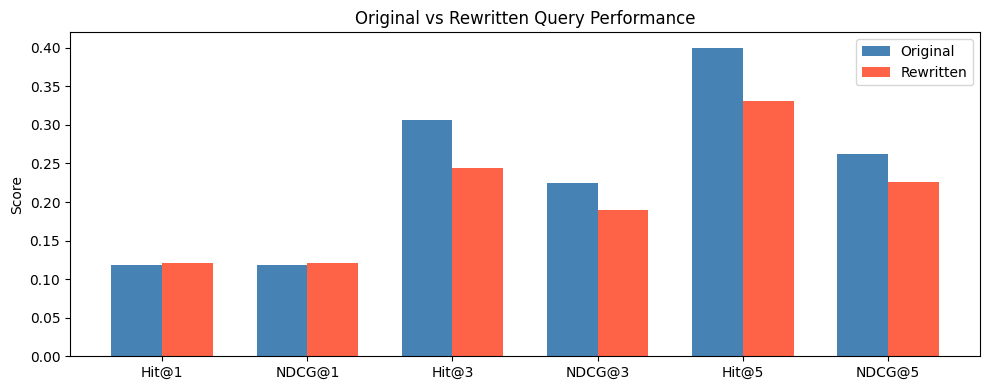

In [99]:
#visualisation
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison.columns))
width = 0.35

bars1 = ax.bar(x - width/2, comparison.loc['Dense (original)'], width, label='Original', color='steelblue')
bars2 = ax.bar(x + width/2, comparison.loc['Dense (rewritten)'], width, label='Rewritten', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(comparison.columns)
ax.set_ylabel('Score')
ax.set_title('Original vs Rewritten Query Performance')
ax.legend()
plt.tight_layout()
plt.savefig('fig_rewriting_comparison.png', dpi=300)
plt.show()